In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [127]:
dataset=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

In [128]:
dataset.head()

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0
0,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
1,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
2,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
3,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
4,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0


In [129]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   1            242 non-null    int64  
 1   6            242 non-null    int64  
 2   2012         242 non-null    int64  
 3   29           242 non-null    int64  
 4   57           242 non-null    int64  
 5   18           242 non-null    int64  
 6   0.0          242 non-null    float64
 7   65.7         242 non-null    float64
 8   3.4          242 non-null    float64
 9   7.6          242 non-null    float64
 10  1.3          242 non-null    float64
 11  3.4.1        242 non-null    float64
 12  0.5          242 non-null    float64
 13  not fire     242 non-null    object 
 14  0            242 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.5+ KB


##### data cleaning

In [130]:
## missing

dataset[dataset.isnull().any(axis=1)]

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0


The dataset is converted into 2 sets based on regions from 122th index , we can make a new column based on the Region

1. "Bejaia region dataset"
2. "Sidi-bel region dataset"

add new column with region

In [131]:
df=dataset

df.loc[:122,"region"]=0
df.loc[122:,"region"]=1

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   1            242 non-null    int64  
 1   6            242 non-null    int64  
 2   2012         242 non-null    int64  
 3   29           242 non-null    int64  
 4   57           242 non-null    int64  
 5   18           242 non-null    int64  
 6   0.0          242 non-null    float64
 7   65.7         242 non-null    float64
 8   3.4          242 non-null    float64
 9   7.6          242 non-null    float64
 10  1.3          242 non-null    float64
 11  3.4.1        242 non-null    float64
 12  0.5          242 non-null    float64
 13  not fire     242 non-null    object 
 14  0            242 non-null    int64  
 15  region       242 non-null    float64
dtypes: float64(8), int64(7), object(1)
memory usage: 30.4+ KB


In [133]:
df[['region']]=df[['region']].astype(int)

In [134]:
df.head()

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0,region
0,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0,0
1,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0,0
2,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0,0
3,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0,0
4,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0,0


In [135]:
df.isnull().sum()

1              0
6              0
2012           0
29             0
57             0
18             0
0.0            0
65.7           0
3.4            0
7.6            0
1.3            0
3.4.1          0
0.5            0
not fire       0
0              0
region         0
dtype: int64

In [136]:
## remove the null values

df=df.dropna().reset_index(drop=True)
df.head()

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0,region
0,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0,0
1,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0,0
2,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0,0
3,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0,0
4,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0,0


In [137]:
df.isnull().sum()

1              0
6              0
2012           0
29             0
57             0
18             0
0.0            0
65.7           0
3.4            0
7.6            0
1.3            0
3.4.1          0
0.5            0
not fire       0
0              0
region         0
dtype: int64

In [138]:
df.iloc[[122]]

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0,region
122,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire,1,1


In [139]:
## remove the 122nd row
df=df.drop(122).reset_index(drop=True)

In [140]:
df.iloc[[122]]

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0,region
122,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire,1,1


In [141]:
df.columns

Index(['1', '6', '2012', '29', '57', '18', '0.0', '65.7', '3.4', '7.6', '1.3',
       '3.4.1', '0.5', 'not fire   ', '0', 'region'],
      dtype='object')

In [142]:
## fix spaces in the column names

df.columns=df.columns.str.strip()

In [143]:
df.columns

Index(['1', '6', '2012', '29', '57', '18', '0.0', '65.7', '3.4', '7.6', '1.3',
       '3.4.1', '0.5', 'not fire', '0', 'region'],
      dtype='object')

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   1         241 non-null    int64  
 1   6         241 non-null    int64  
 2   2012      241 non-null    int64  
 3   29        241 non-null    int64  
 4   57        241 non-null    int64  
 5   18        241 non-null    int64  
 6   0.0       241 non-null    float64
 7   65.7      241 non-null    float64
 8   3.4       241 non-null    float64
 9   7.6       241 non-null    float64
 10  1.3       241 non-null    float64
 11  3.4.1     241 non-null    float64
 12  0.5       241 non-null    float64
 13  not fire  241 non-null    object 
 14  0         241 non-null    int64  
 15  region    241 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 30.3+ KB


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   1         241 non-null    int64  
 1   6         241 non-null    int64  
 2   2012      241 non-null    int64  
 3   29        241 non-null    int64  
 4   57        241 non-null    int64  
 5   18        241 non-null    int64  
 6   0.0       241 non-null    float64
 7   65.7      241 non-null    float64
 8   3.4       241 non-null    float64
 9   7.6       241 non-null    float64
 10  1.3       241 non-null    float64
 11  3.4.1     241 non-null    float64
 12  0.5       241 non-null    float64
 13  not fire  241 non-null    object 
 14  0         241 non-null    int64  
 15  region    241 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 30.3+ KB


In [146]:
### changing the other columns to float datatype

objects=[features for features in df.columns if df[features].dtypes=='O']

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   1         241 non-null    int64  
 1   6         241 non-null    int64  
 2   2012      241 non-null    int64  
 3   29        241 non-null    int64  
 4   57        241 non-null    int64  
 5   18        241 non-null    int64  
 6   0.0       241 non-null    float64
 7   65.7      241 non-null    float64
 8   3.4       241 non-null    float64
 9   7.6       241 non-null    float64
 10  1.3       241 non-null    float64
 11  3.4.1     241 non-null    float64
 12  0.5       241 non-null    float64
 13  not fire  241 non-null    object 
 14  0         241 non-null    int64  
 15  region    241 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 30.3+ KB


In [148]:
df.describe()

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,0,region
count,241.000000,241.000000,241.0,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,15.879668,7.514523,2012.0,32.174274,62.016598,15.493776,0.752697,77.984647,14.777178,49.777178,4.773859,16.802905,7.090871,0.497925,0.493776
std,8.782442,1.110929,0.0,3.634717,14.869422,2.813835,2.000022,14.316097,12.398778,47.710698,4.156874,14.233550,7.446319,0.501036,0.501002
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.600000,5.800000,14.700000,1.400000,6.100000,0.800000,0.000000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.700000,11.300000,33.400000,3.500000,12.500000,4.700000,0.000000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,74.000000,17.000000,0.500000,88.300000,20.900000,71.000000,7.300000,22.900000,11.600000,1.000000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000,1.000000


In [149]:
df.head()

,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4.1,0.5,not fire,0,region
0,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0,0
1,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0,0
2,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0,0
3,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0,0
4,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0,0


In [150]:
## save the cleaned dataset

df.to_csv('Algerian_forest_fires_dataset_UPDATE.csv',index=False)

#### Exploratory data analysis

In [152]:
## drop month day and year
df_copy=df

In [ ]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


Class distribution:
 target
1    0.568465
0    0.431535
Name: proportion, dtype: float64

Numeric columns:
 ['day', 'month', 'year', '29', '57', '18', '0.0', '65.7', '3.4', '7.6', '1.3', '3.4.1', '0.5', '0', 'region', 'target']
Dropping constant cols: ['year']

Top features by mutual information:
 65.7     0.635795
1.3      0.634107
0.5      0.564590
3.4.1    0.346610
3.4      0.334378
7.6      0.301834
0.0      0.260549
29       0.118617
57       0.114118
month    0.088447
dtype: float64

Top features by RandomForest importance:
 1.3      0.285980
65.7     0.252815
0.5      0.176570
3.4      0.079737
7.6      0.059383
3.4.1    0.053509
0.0      0.051848
29       0.014688
57       0.010646
day      0.004741
dtype: float64
Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

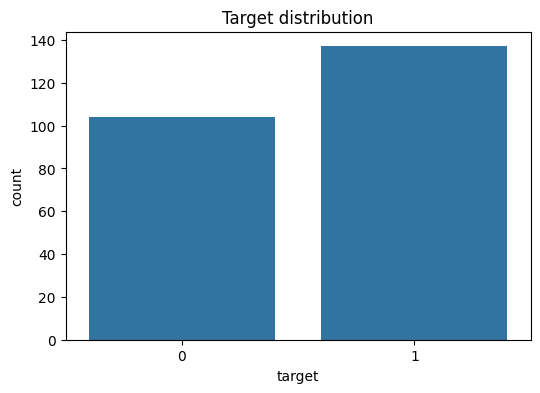

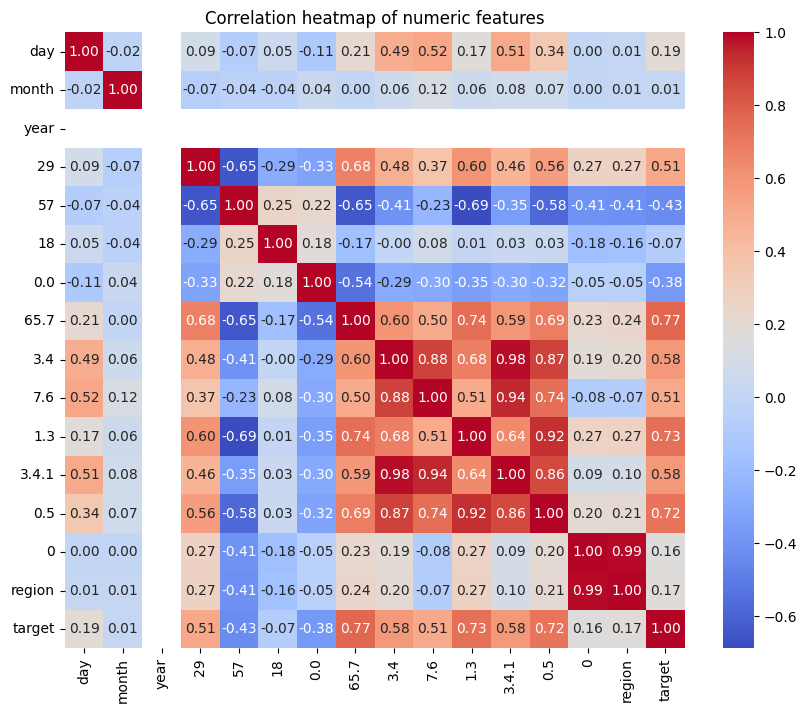

In [155]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Feature selection, EDA, feature engineering, model training & hyperparameter tuning

# Use existing `df` from the notebook
data = df.copy()

# 1) TARGET: convert object target to binary (use the detected object column name)
target_col = objects[0] if objects else None
if not target_col:
  raise ValueError("No object column found for target.")
data['target'] = data[target_col].astype(str).str.strip().map({'fire': 1, 'not fire': 0})
if data['target'].isnull().any():
  # fallback: anything not 'not fire' treat as fire
  data['target'] = data[target_col].astype(str).str.strip().apply(lambda x: 0 if x == 'not fire' else 1)
data = data.drop(columns=[target_col])

# 2) Basic rename for first 3 columns if they correspond to day/month/year (based on values)
cols = data.columns.tolist()
if len(cols) >= 3:
  cols[:3] = ['day', 'month', 'year']
  data.columns = cols

# 3) EDA: class balance and numeric feature overview
print("Class distribution:\n", data['target'].value_counts(normalize=True))
numeric = data.select_dtypes(include=[np.number])
print("\nNumeric columns:\n", numeric.columns.tolist())

# Simple plots (will show inline in notebook)
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=data)
plt.title('Target distribution')

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation heatmap of numeric features')

# 4) Feature engineering: ensure numeric dtype, handle duplicates/constant cols
numeric = numeric.copy().astype(float)
const_cols = [c for c in numeric.columns if numeric[c].nunique() <= 1]
if const_cols:
  print("Dropping constant cols:", const_cols)
  numeric = numeric.drop(columns=const_cols)

# 5) Feature selection: univariate mutual info and tree-based importances

X = numeric.drop(columns=['target']) if 'target' in numeric.columns else numeric
y = data['target']

# mutual information
mi = SelectKBest(mutual_info_classif, k=min(10, X.shape[1])).fit(X, y)
mi_scores = pd.Series(mi.scores_, index=X.columns).sort_values(ascending=False)
print("\nTop features by mutual information:\n", mi_scores.head(10))

# quick tree-based importance
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_temp.fit(X, y)
imp = pd.Series(rf_temp.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features by RandomForest importance:\n", imp.head(10))

# 6) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 7) Modeling pipeline & hyperparameter tuning (RandomForest)

pipe = Pipeline([
  ('scaler', StandardScaler()),       # scaling is harmless for RF
  ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
  'clf__n_estimators': [100, 250, 500],
  'clf__max_depth': [None, 6, 12, 20],
  'clf__min_samples_split': [2, 5, 10],
  'clf__class_weight': [None, 'balanced']
}

gs = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("\nBest params:", gs.best_params_)
print("Best CV ROC AUC:", gs.best_score_)

# 8) Evaluate on test set
best = gs.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]
print("\nTest ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# 9) Final feature importances from best RF
final_imp = pd.Series(best.named_steps['clf'].feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFinal feature importances:\n", final_imp.head(10))

# 10) Optionally: reduce to top features and retrain (simple experiment)
top_k = final_imp.head(6).index.tolist()
print("\nRetraining using top features:", top_k)
Xtr = X_train[top_k]
Xte = X_test[top_k]
best_small = RandomForestClassifier(**{k.replace('clf__',''):v for k,v in gs.best_params_.items() if k.startswith('clf__')}, random_state=42, n_jobs=-1)
best_small.fit(Xtr, y_train)
y_pred_small = best_small.predict(Xte)
print("\nSmall model Test ROC AUC:", roc_auc_score(y_test, best_small.predict_proba(Xte)[:,1]))
print("\nSmall model classification report:\n", classification_report(y_test, y_pred_small, digits=4))